## Word2Vec описание

##### word2vec это метод обучения векторных представлений слов по их контексту. Его основной результат — embeddings, в которых семантически похожие слова расположены близко.

Word2Vec — это популярная модель обучения вложений слов, предложенная исследователями Google в 2013 году (Томас Миколов). 
Она позволяет преобразовать слова из корпуса текстов в векторы чисел таким образом, что слова с похожими семантическими значениями имеют близкие векторные представления в многомерном пространстве. 
Это делает Word2Vec мощным инструментом для задач обработки естественного языка (NLP), таких как анализ тональности, машинный перевод, автоматическое резюмирование и многие другие.

Основные характеристики Word2Vec:
* Распределенное представление: Каждое слово представляется вектором в многомерном пространстве, где отношения между словами отражаются через косинусное сходство между их векторами.
* Обучение без учителя: Word2Vec обучается на больших неразмеченных текстовых корпусах без необходимости во внешних аннотациях или разметке.
* Контекстное обучение: Векторы слов получаются на основе контекста, в котором эти слова встречаются, что позволяет захватить их семантические и синтаксические отношения.


Для демонстрации, как word2vec преобразует слова с похожими семантическими значениями в близкие векторные представления, можно рассмотреть пример с такими словами, как "кофе" и "чай". В многомерном пространстве эти слова будут находиться близко друг к другу, потому что они оба относятся к категории напитков и часто употребляются в схожих контекстах.
Пример:
Рассмотрим слова: "кофе", "чай", "вода", и "автомобиль".
В многомерном векторном пространстве, созданном с помощью модели word2vec, "кофе" и "чай" будут иметь векторы, расположенные близко друг к другу из-за их семантической близости как напитков.
Слово "вода" также будет находиться рядом с "кофе" и "чай", так как это тоже напиток.
В то же время, слово "автомобиль" будет располагаться в совершенно другой части векторного пространства, поскольку оно относится к совершенно другой категории — транспортным средствам.

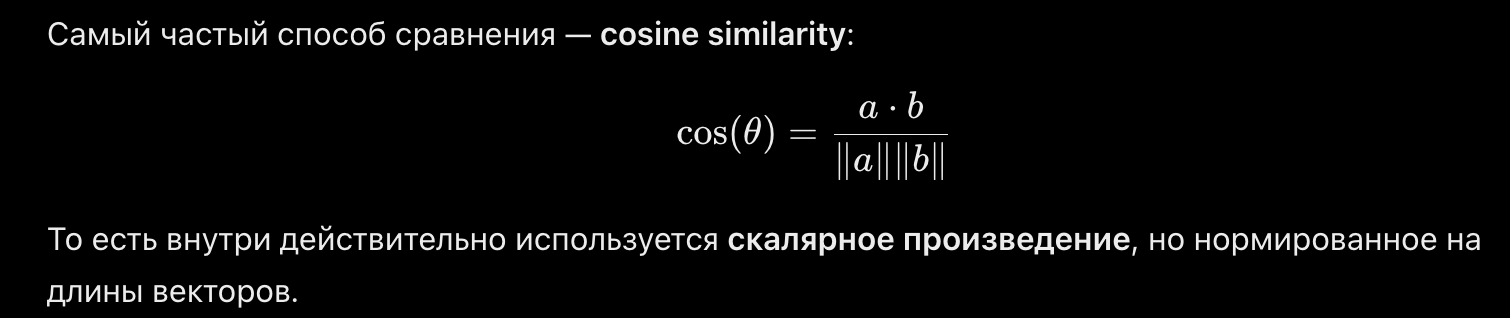

Две основные архитектуры модели Word2Vec:
* CBOW (Continuous Bag of Words): Этот подход предсказывает текущее слово на основе контекста вокруг него. Например, для фразы "синее небо над головой", модель CBOW будет пытаться предсказать слово "небо" на основе контекстных слов "синее", "над", "головой". CBOW быстро обрабатывает большие объемы данных, но менее эффективен для редких слов.
* Skip-Gram: В этом подходе наоборот, используется текущее слово для предсказания слов в его контексте. Для того же примера, модель Skip-Gram будет пытаться предсказать слова "синее", "над", "головой" на основе слова "небо". Skip-Gram медленнее обрабатывает данные, но лучше работает с редкими словами и менее частыми контекстами.

## CBOW (Continuous Bag of Words)
Целью CBOW является предсказание целевого слова на основе контекста вокруг этого слова. Контекст определяется как набор слов вокруг целевого слова в пределах заданного окна. Архитектура модели упрощенно представляет собой трехслойную нейронную сеть: входной слой, скрытый слой и выходной слой.
Входной слой: На вход модели подаются контекстные слова. Эти слова представляются в виде векторов с использованием "one-hot encoding", где каждый вектор имеет размерность, равную размеру словаря, и содержит 1 на позиции, соответствующей индексу слова в словаре, и 0 в остальных позициях.
Скрытый слой: Векторы входных слов умножаются на матрицу весов между входным и скрытым слоем, результатом чего является вектор скрытого слоя. Для CBOW вектора контекстных слов обычно усредняются перед передачей на следующий слой.
Выходной слой: Вектор скрытого слоя умножается на матрицу весов между скрытым и выходным слоем, результат чего проходит через softmax-функцию для получения вероятностей каждого слова в словаре быть целевым словом. Цель обучения - максимизировать вероятность правильного целевого слова.
Кодируем через one-hot-encoding
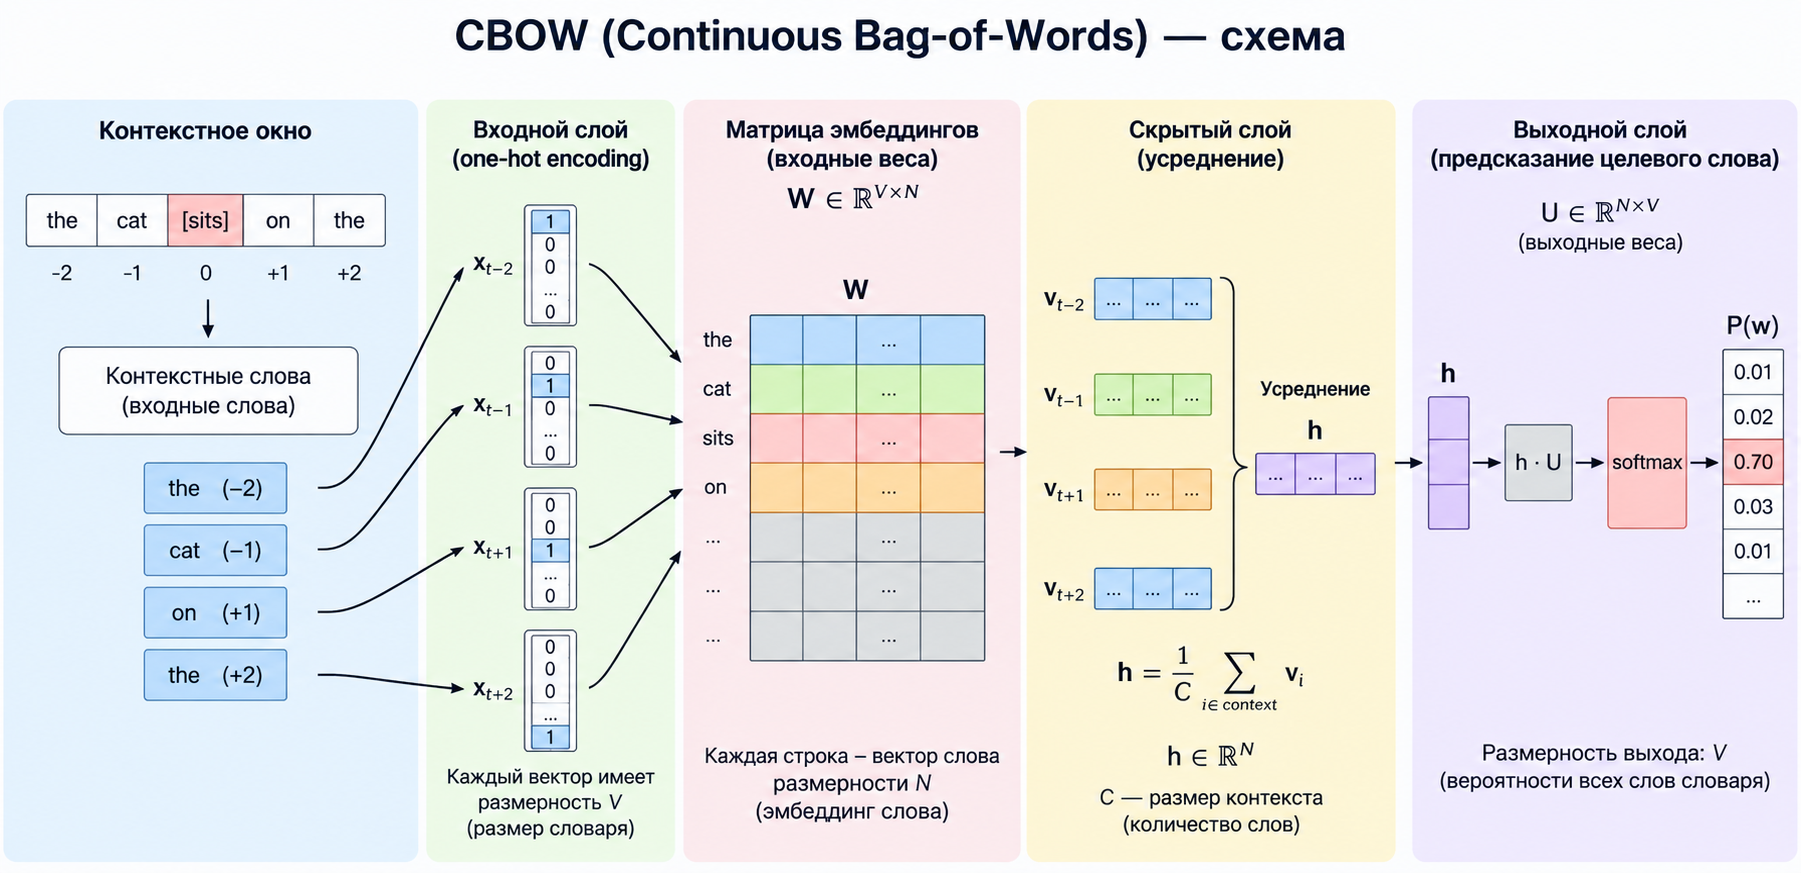
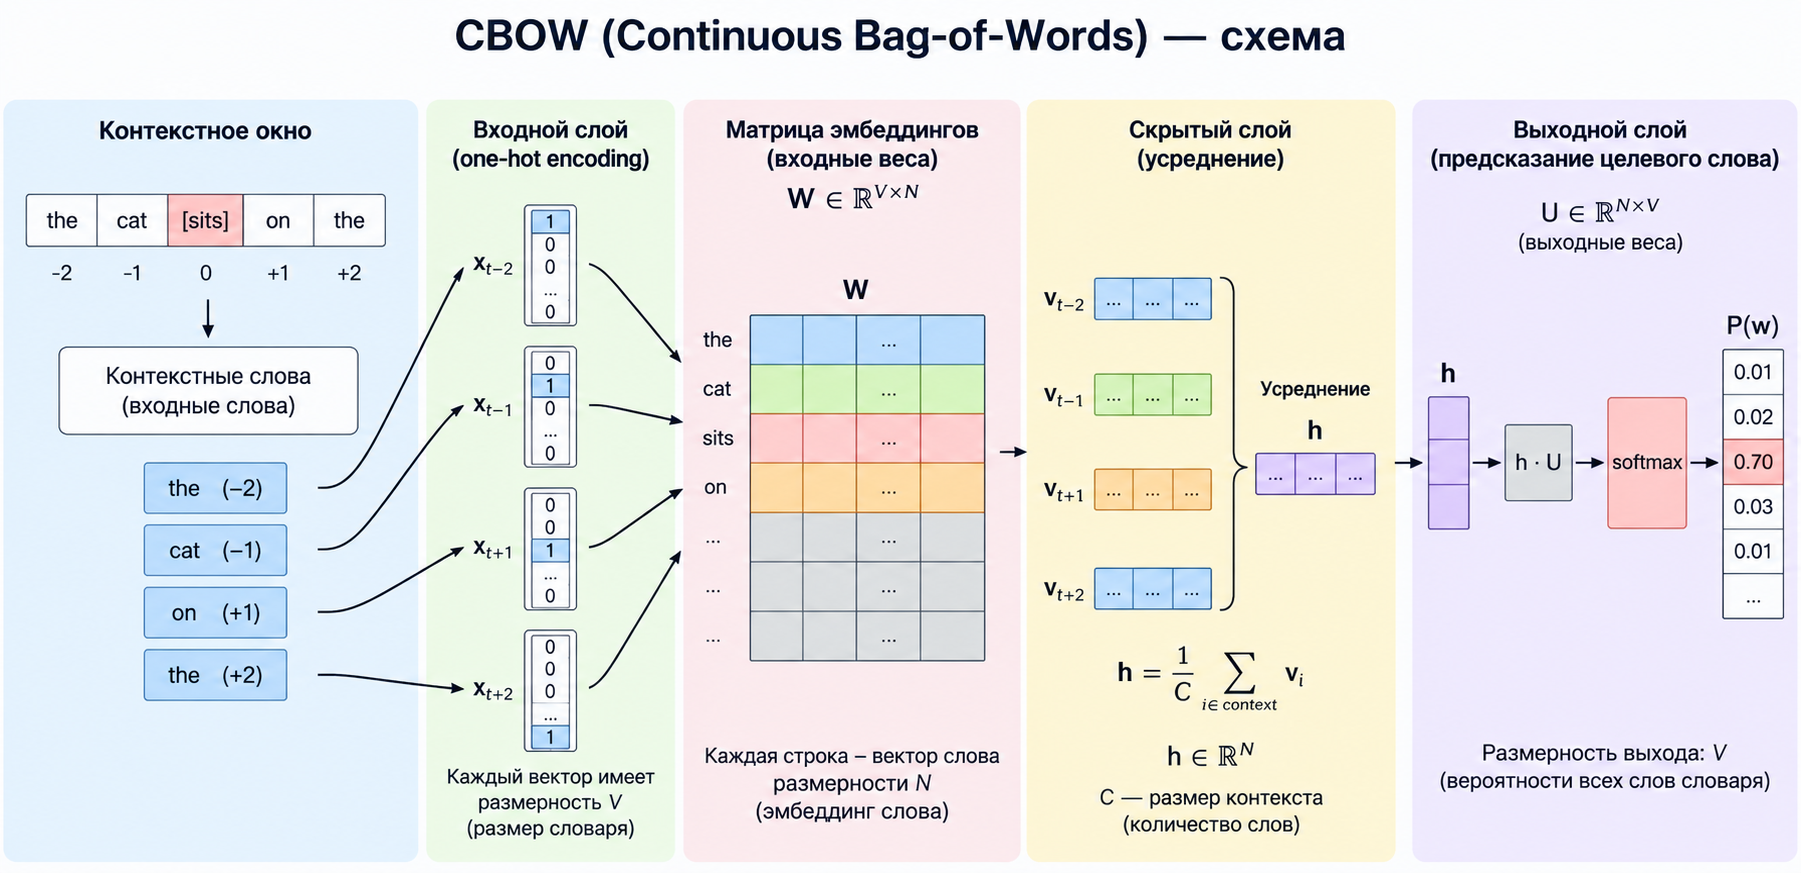

## Skip-Gram
В отличие от CBOW, цель Skip-Gram - предсказать контекстные слова для данного целевого слова. Это слово на входе модели используется для предсказания слов в его контексте в пределах заданного диапазона слов (называют окном).
Входной слой: Входом является целевое слово, представленное вектором one-hot.
Скрытый слой: Такой же, как и в CBOW, где вектор целевого слова умножается на матрицу весов, ведущую к скрытому слою.
Выходной слой: В отличие от CBOW, где выходной слой представляет собой один softmax, в Skip-Gram для каждого слова в контексте используется отдельный softmax, что означает, что модель пытается предсказать каждое контекстное слово отдельно. Цель обучения - максимизировать вероятность появления реальных контекстных слов для данного целевого слова.
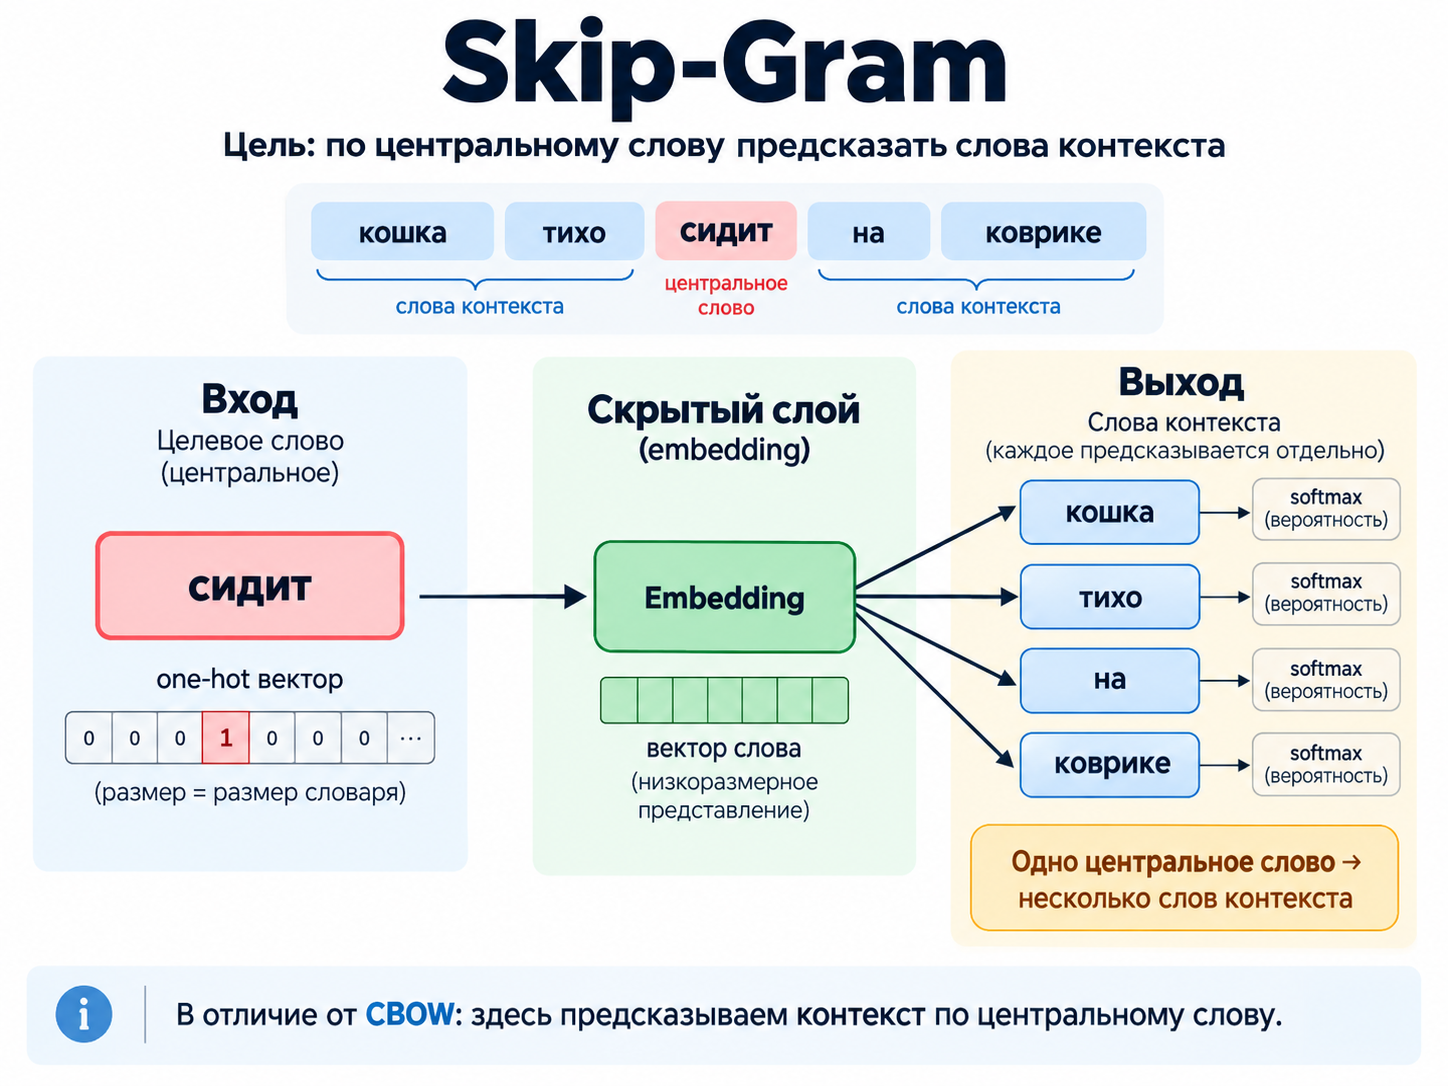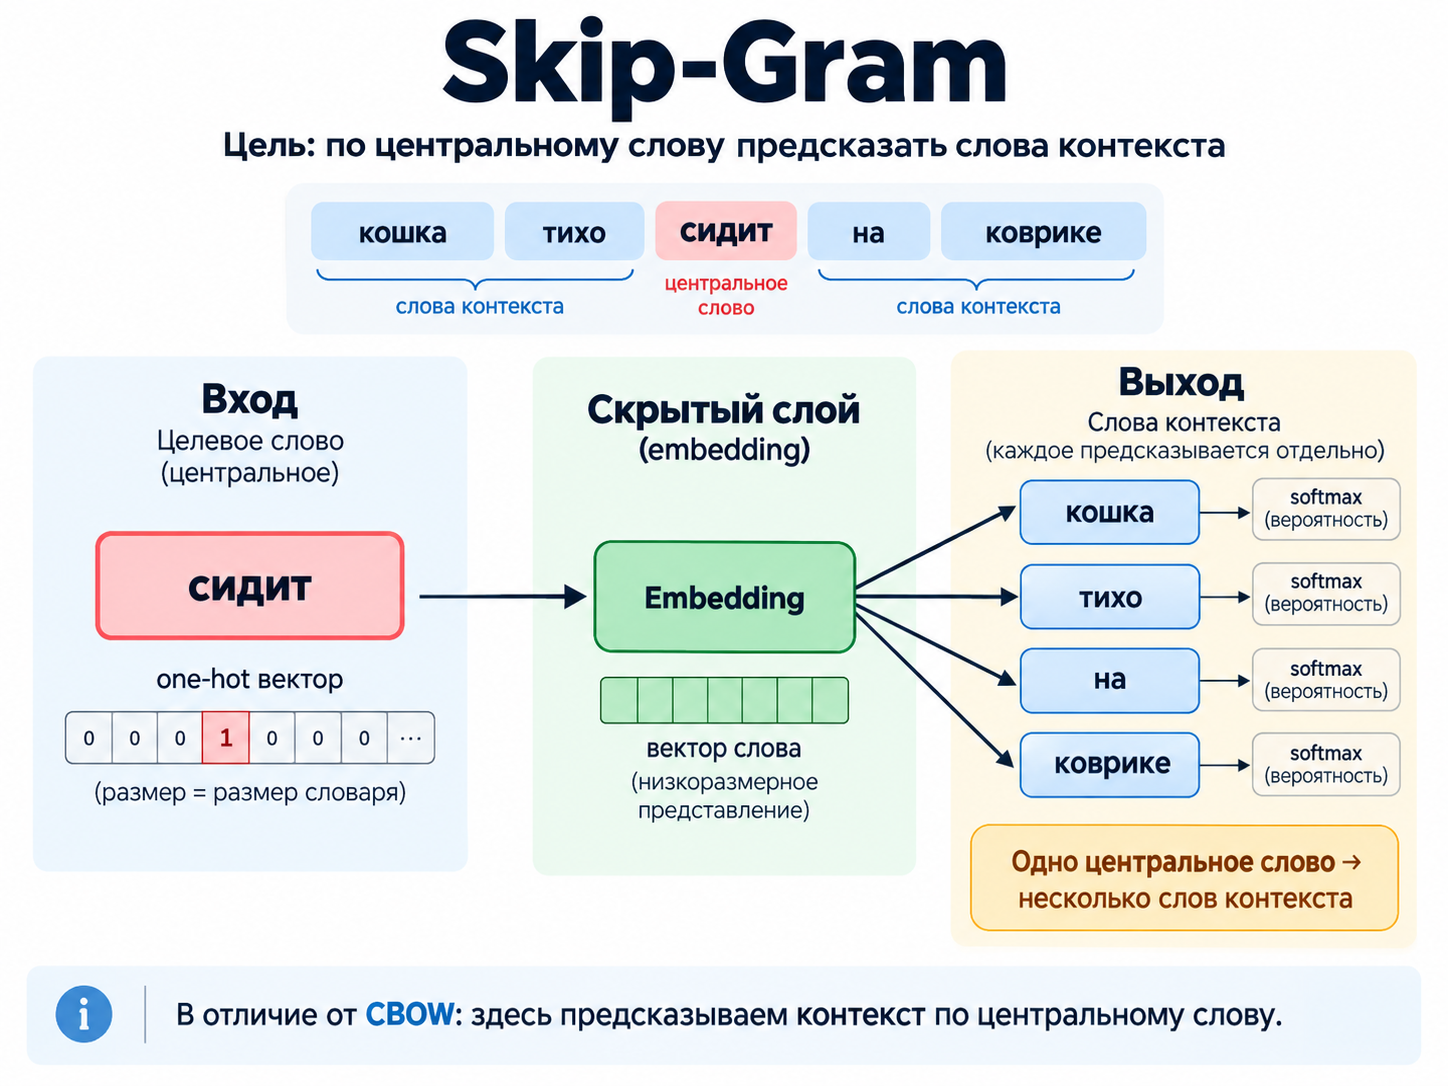

## Реализация на Pytorch!
Реализуем модель Word2Vec с архитектурой Skip-Gram с использованием библиотеки PyTorch. 

In [1]:
import re
from collections import Counter

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

## Skip-Gram:

Подготовка данных
Для начала нам нужно подготовить наши данные. В этом примере мы опустим этап предобработки и сосредоточимся на самой модели. Предположим, у нас уже есть словарь соответствия слов к индексам и наоборот, а также данные для обучения в формате пар (центральное слово, контекстное слово).

In [2]:
def prepare_data(text, window_size=2):
	# Удаляем все символы кроме a-z, @, и #
	text = re.sub(r'[^a-z@# ]', '', text.lower())    
	# Разбиваем по словам
	tokens = text.split()    
	# Формируем словарь уникальных слов
	vocab = set(tokens)
	# Формируем слова слов с указанием индекса  слова в словаре
	word_to_ix = {word: i for i, word in enumerate(vocab)}
	# Формируем пары слов n-грамм
	data = []
	for i in range(len(tokens)):
		for j in range(max(0, i - window_size), min(len(tokens), i + window_size + 1)):
			if i != j:
				data.append((tokens[i], tokens[j]))    
	return data, word_to_ix, len(vocab)

Определение модели Skip-Gram

Установим структуру датасета для даталоадера, можно обойтись и без этого, однако это позволяет масштабировать проект и возможно пригодится нам в дальнейшем. 

Для класса Dataset требуются следующие три метода:
- __init__: выполняется при создании экземпляра класса. Обычно здесь определяются атрибуты.
- __len__: должно возвращать длину набора данных. Это важно для понимания того, сколько памяти выделить.
- __getitem__: учитывая индекс, возражает данные в виде батча (набор данных установленной длины), соответствующий этому индексу.

In [3]:
class SkipGramModelDataset(Dataset):
	def __init__(self, data, word_to_ix):
		self.data = [(word_to_ix[center], word_to_ix[context]) for center, context in data]	
	def __len__(self):
		return len(self.data)	
	def __getitem__(self, idx):
		return torch.tensor(self.data[idx][0], dtype=torch.long), torch.tensor(self.data[idx][1], dtype=torch.long)
		

Определим структуру нашей модели на PyTorch.

Структуру модели примем простой, входной слой - nn.Embedding стандартный для задач NLP, представляет собой векторное представление (вложений) слов. Далее идёт линейный слой. В завершении используем логарифмированную функцию softmax.

LogSoftmax обычно применяется к последнему слою нейронной сети перед вычислением функции потерь, например, NLLLoss (Negative Log Likelihood Loss). LogSoftmax преобразует логиты (выходы линейного слоя) в логарифмированные вероятности, которые затем можно напрямую использовать с NLLLoss. Важно, что NLLLoss ожидает, что входные данные для неё будут в формате логарифмированных вероятностей.

In [4]:
class Word2VecSkipGramModel(nn.Module):
	def __init__(self, vocab_size, embedding_dim):
		super(Word2VecSkipGramModel, self).__init__()
		self.embeddings = nn.Embedding(vocab_size, embedding_dim)
		self.out_layer = nn.Linear(embedding_dim, vocab_size)
		self.activation_function = nn.LogSoftmax(dim=-1)

	def forward(self, center_word_idx):
		hidden_layer = self.embeddings(center_word_idx)
		out_layer = self.out_layer(hidden_layer)
		log_probs = self.activation_function(out_layer)
		return log_probs


## Обучение модели
Общий подход:

- Инициализация- сначала векторы слов инициализируются случайными значениями.
- Прогнозирование контекста - для каждого слова в обучающем корпусе модель использует его векторное представление (выход первого слоя нейронной сети) для предсказания векторов слов в его контексте (через выход второго слоя и функцию softmax).
- Оптимизация - функция потерь оптимизируется для улучшения предсказаний контекста. Это обновляет вектора слов в процессе обучения.
- Итерации - процесс повторяется на протяжении нескольких эпох обучения.

In [5]:
def train_model(data, word_to_ix, vocab_size, embedding_dim=50, epochs=10, batch_size=1):
	# Формируем набор данных
	dataset = SkipGramModelDataset(data, word_to_ix)
	dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
	# модель
	model = Word2VecSkipGramModel(vocab_size, embedding_dim)
	# функция потерь
	loss_function = nn.NLLLoss()
	#  оптимизатор
	optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

	for epoch in range(epochs):
		total_loss = 0
		for center_word, context_word in dataloader:
			model.zero_grad()
			log_probs = model(center_word)
			loss = loss_function(log_probs, context_word)
			loss.backward()
			optimizer.step()            
			total_loss += loss.item()			
		print(f'Epoch {epoch + 1}, Loss: {total_loss}')
	return model

In [6]:
# Основная функция для вызова
def train(data: str):
	# Гиперпараметры:
	# размер окна
	window_size = 2
	# длина ембединга
	embedding_dim = 10
	# количество эпох обучения
	epochs = 5
	# размер батча
	batch_size = 1
	
	# предобработка данных
	ngramm_data, word_to_ix, vocab_size = prepare_data(data, window_size) 
	# основной процесс формирование и обучения модели
	model = train_model(ngramm_data, word_to_ix, vocab_size, embedding_dim, epochs, batch_size)
	
	# # Извлекаем векторы слов из модели
	embeddings = model.embeddings.weight.data.numpy()
	# формируем словарь слов и их векторное представление
	ix_to_word = {i: word for word, i in word_to_ix.items()}
	w2v_dict = {ix_to_word[ix]: embeddings[ix] for ix in range(vocab_size)}
	return w2v_dict


In [7]:
# Гиперпараметры выбраны исключительно в учебных целях.
# Тестовые данные
test_text = 'Captures Semantic Relationships: The skip-gram model effectively captures semantic relationships between words. It learns word embeddings that encode similar meanings and associations, allowing for tasks like word analogies and similarity calculations. Handles Rare Words: The skip-gram model performs well even with rare words or words with limited occurrences in the training data. It can generate meaningful representations for such words by leveraging the context in which they appear. Contextual Flexibility: The skip-gram model allows for flexible context definitions by using a window around each target word. This flexibility captures local and global word associations, resulting in richer semantic representations. Scalability: The skip-gram model can be trained efficiently on large-scale datasets due to its simplicity and parallelization potential. It can process vast amounts of text data to generate high-quality word embeddings.'

w2v_dict = train(test_text)

Epoch 1, Loss: 2350.8378677368164
Epoch 2, Loss: 2151.2560831308365
Epoch 3, Loss: 2049.491655945778
Epoch 4, Loss: 1980.5934714078903
Epoch 5, Loss: 1923.6451370716095


Мы создаем датасет с центральными словами и их контекстами, правильно формируем входы и цели для обучения.
Модель Word2VecSkipGramModel принимает индекс центрального слова, возвращает логарифмированные вероятности для всех слов в словаре.
В функции обучения train_model используем NLLLoss для вычисления потерь между предсказанными логарифмированными вероятностями.

## CBOW:
В этом подходе, модель предсказывает текущее слово на основе контекста вокруг него. Это значит, что на вход модели подаются несколько слов из контекста текущего слова, и модель учится предсказывать это текущее слово.

#### Основные изменения
Подготовка данных

Меняем функцию подготовки данных так, чтобы она создавала обучающие примеры, состоящие из контекстных слов в качестве входных данных и центрального слова как цели:

In [8]:
def prepare_data_cbow(text: str, window_size=2):
	text = re.sub(r'[^a-z@# ]', '', text.lower())    
	tokens = text.split()    
	vocab = set(tokens)
	word_to_ix = {word: i for i, word in enumerate(vocab)}
	data = []
	for i in range(window_size, len(tokens) - window_size):
		context = [tokens[i - j - 1] for j in range(window_size)] + [tokens[i + j + 1] for j in range(window_size)]
		target = tokens[i]
		data.append((context, target))
	return data, word_to_ix, len(vocab)	

class SkipGramDataset(Dataset):
	def __init__(self, data, word_to_ix):			
		self.data = [(word_to_ix[center], word_to_ix[context]) for center, context in data]
	
	def __len__(self):
		return len(self.data)
	
	def __getitem__(self, idx):
		return torch.tensor(self.data[idx][0], dtype=torch.long), torch.tensor(self.data[idx][1], dtype=torch.long)

Изменение архитектуры модели

Модифицируем модель так, чтобы она принимала контекстные слова и предсказывала центральное слово:

In [9]:
class Word2VecCBOWModel(nn.Module):
	def __init__(self, vocab_size, embedding_dim):
		super(Word2VecCBOWModel, self).__init__()
		self.embeddings = nn.Embedding(vocab_size, embedding_dim)
		self.out_layer = nn.Linear(embedding_dim, vocab_size)
		self.activation_function = nn.LogSoftmax(dim=1)

	def forward(self, center_word_idx):
		hidden_layer = torch.mean(self.embeddings(center_word_idx), dim=1)
		out_layer = self.out_layer(hidden_layer)
		log_probs = self.activation_function(out_layer)
		return log_probs


In [10]:
def train_model_cbow(data, word_to_ix, vocab_size, embedding_dim=50, epochs=10, batch_size=1):
	dataset = CBOWDataset(data, word_to_ix)
	dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
	model = Word2VecCBOWModel(vocab_size, embedding_dim)
	loss_function = nn.NLLLoss()
	optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
	for epoch in range(epochs):
		total_loss = 0
		for context_words, target_word in dataloader:
			context_words = context_words
			model.zero_grad()
			log_probs = model(context_words)
			loss = loss_function(log_probs, target_word)
			loss.backward()
			optimizer.step()
			total_loss += loss.item()
		print(f'Epoch {epoch + 1}, Loss: {total_loss}')
	return model

## Улучшения производительности
Для повышения качества модели Word2Vec можно применить ряд методов и техник:

1. Увеличение объема тренировочных данных.
   * Больше текстовых данных: Больший и более разнообразный тренировочный корпус может помочь модели лучше понять различные контексты использования слов и улучшить качество векторных представлений.
2. Предобработка данных.
   * Токенизация: Эффективное разбиение текста на слова, предложения и другие значимые единицы.
   * Удаление стоп-слов: Исключение часто встречающихся слов, которые могут не нести значимой семантической нагрузки (например, предлоги, союзы).
   * Лемматизация и стемминг: Приведение слов к их базовой форме может помочь снизить размер словаря и уменьшить шум.
   * Использование n-грамм: Обучение модели на фразах или комбинациях слов (например, "Нью-Йорк" вместо "Нью" и "Йорк" отдельно) может улучшить качество вложений для составных терминов.
3. Настройка гиперпараметров
   * Размер вектора: Увеличение размера векторного представления слов может улучшить качество, захватывая больше нюансов семантики, но также увеличивает требования к вычислительным ресурсам и памяти.
   * Размер окна контекста: Экспериментирование с размером окна может помочь настроить баланс между изучением ближайшего контекста и более широкими контекстуальными отношениями.
   * Частота обновления (subsampling): Игнорирование чрезмерно часто встречающихся слов во время обучения может улучшить общее качество модели.
   * Количество эпох: Увеличение количества проходов по датасету может помочь модели лучше обучиться, но с риском переобучения.
4. Negative Sampling и Hierarchical Softmax
   * Количество негативных образцов: Настройка количества негативных образцов для каждого положительного образца может влиять на скорость и качество обучения.
   * Использование иерархического софтмакса: Может ускорить обучение для очень больших словарей за счет более эффективного расчета вероятностей.
5. Использование ансамблей и мультимодальных данных
   * Ансамбли моделей: Комбинирование предсказаний нескольких моделей может улучшить общее качество вложений.
   * Мультимодальное обучение: Интеграция информации из различных источников (текст, изображения, звук) может помочь создать более богатые и разнообразные представления слов.

## Fasttext!

FastText — это по сути модификация - Word2Vec + subword information. Он понадобился, чтобы лучше работать с редкими, незнакомыми и морфологически похожими словами.

Например:
"playing"

FastText может разбить примерно на куски:
- pla
- lay
- ayi
- yin
- ing
- ...

И embedding слова формируется из embeddings этих подслов.
Зачем это нужно:
- лучше работает с редкими словами;
- умеет получать embedding для OOV-слов;
- лучше учитывает морфологию;
- особенно полезен для языков с богатым словоизменением, например русского.
Простой пример:
- работа
- работать
- работающий
- работник

В Word2Vec это четыре отдельных слова.

В FastText у них много общих символьных n-грамм, поэтому модели проще понять, что они связаны.И важный нюанс: FastText всё ещё даёт статический embedding слова, то есть bank будет иметь один и тот же вектор в разных контекстах. Это уже позже решают контекстные модели вроде BERT.